In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns


In [37]:
cad_data = pd.read_csv('call_data_from_CAD.csv')
cad_data = cad_data.drop('Unnamed: 0', axis=1)
cad_data['IncidentNumber'] = cad_data['IncidentNumber'].str.extract(r'(\d+)$')
cad_data.tail()

,IncidentNumber,Call_Created_Time,Call_First_Dispatched_Time,Call_First_On_Scene,Call_Cleared,Call_Zipcode,Beat,Call_Source,Call_Priority,InitialIncidentTypeDescription,IsPrimary,PrimaryUnitCallSign,RespondingUnitCallSign,Unit_Dispatched_Time,Unit_OnScene_Time,Unit_Cleared_Time,Disposition
1048570,19218648,8/22/19 17:54,8/22/19 18:00,8/22/19 18:04,8/22/19 18:21,97404.0,EP06,PHONE,3,UNATTENDED CHILDREN,0,4U51,3K98,8/22/19 18:00,8/22/19 18:04,8/22/19 18:16,PATROL CHECK
1048571,19218648,8/22/19 17:54,8/22/19 18:00,8/22/19 18:04,8/22/19 18:21,97404.0,EP06,PHONE,3,UNATTENDED CHILDREN,1,4U51,4U51,8/22/19 18:00,8/22/19 18:09,8/22/19 18:21,PATROL CHECK
1048572,19218649,8/22/19 17:56,NaN,NaN,NaN,97402.0,EP05,PHONE,P,THEFT,0,NaN,NaN,NaN,NaN,NaN,REPORT TAKEN
1048573,19218652,8/22/19 17:58,8/22/19 18:03,8/22/19 18:03,8/22/19 18:24,97402.0,EP05,PHONE,1,MOTOR VEH ACC UNKNOWN INJ,1,3E71,3E71,8/22/19 18:03,8/22/19 18:03,8/22/19 18:24,ASSISTED
1048574,19218653,8/22/19 18:01,NaN,NaN,NaN,97402.0,EP04,W911,3,CRIMINAL TRESPASS,0,NaN,NaN,NaN,NaN,NaN,RESOLVED


In [38]:
d25 = pd.read_csv('./yearly/class_data_2025.csv', low_memory=False)
d24 = pd.read_csv('./yearly/class_data_2024.csv', low_memory=False)
d23 = pd.read_csv('./yearly/class_data_2023.csv', low_memory=False)
d22 = pd.read_csv('./yearly/class_data_2022.csv', low_memory=False)
d21 = pd.read_csv('./yearly/class_data_2021.csv', low_memory=False)
d20 = pd.read_csv('./yearly/class_data_2020.csv', low_memory=False)
d19 = pd.read_csv('./yearly/class_data_2019.csv', low_memory=False)
d18 = pd.read_csv('./yearly/class_data_2018.csv', low_memory=False)
d17 = pd.read_csv('./yearly/class_data_2017.csv', low_memory=False)
d16 = pd.read_csv('./yearly/class_data_2016.csv', low_memory=False)
d15 = pd.read_csv('./yearly/class_data_2015.csv', low_memory=False)
d14 = pd.read_csv('./yearly/class_data_2014.csv', low_memory=False)
d_list = [d25, d24, d23, d22, d21, d20, d19, d18, d17, d16, d15, d14]

In [39]:
df = pd.concat([d14, d15, d16, d17, d18, d19, d20, d21, d22, d23, d24, d25], ignore_index=True)
df.tail()

,yr,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,beat,priority,zip,primeunit,units_dispd,units_arrived
1488572,2025,LAW,25103164,2025-04-22 23:34:57.000,NaN,W911,"GAS LEAK, LARGE STRUCTURE",INFO,INFORMATION ONLY,NaN,NaN,1246,0,0,EP07,P,97401,NaN,0,0
1488573,2025,LAW,25103169,2025-04-22 23:48:35.000,NaN,W911,BEAT INFORMATION,INFO,INFORMATION ONLY,2826.0,NaN,2828,1,0,EP02,5,97401,6E31,1,1
1488574,2025,LAW,25103175,2025-04-22 23:51:33.000,2506437,W911,TRASH BIN FIRE,REPT,REPORT TAKEN,412.0,NaN,2249,1,0,EP05,P,97402,6E64,1,1
1488575,2025,LAW,25103180,2025-04-22 23:59:31.000,NaN,PHONE,CHECK WELFARE,REL,REFERRED TO OTHER AGENCY,NaN,NaN,1649,0,0,EP02,3,97401,NaN,0,0
1488576,2025,LAW,25103312,2025-04-18 11:12:00.000,2506445,RPTO,BURGLARY,REPT,REPORT TAKEN,NaN,NaN,0,0,0,EP05,P,97402,NaN,0,0


In [40]:
df['calltime'] = pd.to_datetime(df['calltime'])
df['date'] = df['calltime'].dt.date
df['calltime'] = df['calltime'].dt.time

In [41]:
df = df.drop(columns=['case_id', 'inci_id', 'closecode', 'closed_as', 'secs_to_disp', 'secs_to_arrv', 'secs_to_close', 'disp', 'arrv', 'units_dispd', 'units_arrived'], axis=1)
df.tail()

,yr,service,calltime,callsource,nature,beat,priority,zip,primeunit,date
1488572,2025,LAW,23:34:57,W911,"GAS LEAK, LARGE STRUCTURE",EP07,P,97401,NaN,2025-04-22
1488573,2025,LAW,23:48:35,W911,BEAT INFORMATION,EP02,5,97401,6E31,2025-04-22
1488574,2025,LAW,23:51:33,W911,TRASH BIN FIRE,EP05,P,97402,6E64,2025-04-22
1488575,2025,LAW,23:59:31,PHONE,CHECK WELFARE,EP02,3,97401,NaN,2025-04-22
1488576,2025,LAW,11:12:00,RPTO,BURGLARY,EP05,P,97402,NaN,2025-04-18


In [42]:
#df['primeunit'].unique().sum()
#df['primeunit'].str.startswith('CAHOOT').sum()

In [43]:
df_clean = df.dropna(subset=['primeunit'])
cahoot = df_clean[df_clean['primeunit'].str.startswith('CAHOOT')]

not_c = df_clean[~df_clean['primeunit'].str.startswith('CAHOOT')]

epd = not_c.drop(columns=['primeunit'])


In [44]:
cahoot['date'] = pd.to_datetime(df['date'])
epd['date'] = pd.to_datetime(df['date'])

cutoff = pd.Timestamp('2024-08-01')

before = cahoot[cahoot['date'] < cutoff]
after = cahoot[cahoot['date'] >= cutoff]

bepd = epd[epd['date'] < cutoff]
aepd = epd[epd['date'] >= cutoff]

/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/3036261867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cahoot['date'] = pd.to_datetime(df['date'])


before = 171,446 rows
after = 11,135 rows 
bepd = 889,007 rows
aepd = 61,504 rows

In [45]:
before['group'] = 'CAHOOTS'
before['period'] = 'before'

after['group'] = 'CAHOOTS'
after['period'] = 'after'

bepd['group'] = 'EPD'
bepd['period'] = 'before'

aepd['group'] = 'EPD'
aepd['period'] = 'after'

# Combine all four into a single DataFrame
df_combined = pd.concat([before, after, bepd, aepd], ignore_index=True)


/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/4098078998.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before['group'] = 'CAHOOTS'
/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/4098078998.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before['period'] = 'before'
/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/4098078998.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [46]:
import pandas as pd
from scipy.stats import chi2_contingency

top_natures = df_combined['nature'].value_counts().nlargest(20).index

results = []

for nature_type in top_natures:
    contingency = pd.crosstab(
        index=df_combined['group'],
        columns=df_combined['period'],
        values=(df_combined['nature'] == nature_type),
        aggfunc='sum'
    ).fillna(0).astype(int)

    if (contingency.values < 5).any():
        continue

    chi2, p, dof, expected = chi2_contingency(contingency.values)

    results.append({
        'nature': nature_type,
        'CAHOOTS_before': contingency.loc['CAHOOTS', 'before'],
        'CAHOOTS_after': contingency.loc['CAHOOTS', 'after'],
        'EPD_before': contingency.loc['EPD', 'before'],
        'EPD_after': contingency.loc['EPD', 'after'],
        'chi2': chi2,
        'p_value': p,
        'significant': p < 0.05
    })

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values('p_value')

#print(results_df_sorted.to_string(index=False))
import pandas as pd
from scipy.stats import chi2_contingency

top_natures = df_combined['nature'].value_counts().nlargest(20).index

for nature in top_natures:
    contingency = pd.crosstab(
        df_combined['group'],
        df_combined['period'],
        values=(df_combined['nature'] == nature),
        aggfunc='sum'
    ).fillna(0).astype(int)
    
    if contingency.shape != (2, 2):
        print(f"Skipping '{nature}' due to missing data in one or more groups.")
        continue

    chi2, p, dof, expected = chi2_contingency(contingency.values)

    print(f"\nNature: {nature}")
    print("Contingency Table:")
    print(contingency)
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print("Statistically significant" if p < 0.05 else "Not statistically significant")



Nature: TRAFFIC STOP
Contingency Table:
period   after  before
group                 
CAHOOTS      0      29
EPD       8889  118849
Chi-square statistic: 1.2271
P-value: 0.2680
Not statistically significant

Nature: PATROL CHECK
Contingency Table:
period   after  before
group                 
CAHOOTS      2     269
EPD       6523   89785
Chi-square statistic: 14.6807
P-value: 0.0001
Statistically significant

Nature: CHECK WELFARE
Contingency Table:
period   after  before
group                 
CAHOOTS      7   36776
EPD       2410   28845
Chi-square statistic: 2915.5010
P-value: 0.0000
Statistically significant

Nature: DISPUTE
Contingency Table:
period   after  before
group                 
CAHOOTS      0     248
EPD       4115   58795
Chi-square statistic: 16.2952
P-value: 0.0001
Statistically significant

Nature: CRIMINAL TRESPASS
Contingency Table:
period   after  before
group                 
CAHOOTS      0     660
EPD       4716   50420
Chi-square statistic: 60.5640
P-value: 0.

/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/1484325678.py:36: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  g = sns.catplot(


<Figure size 1800x1000 with 0 Axes>

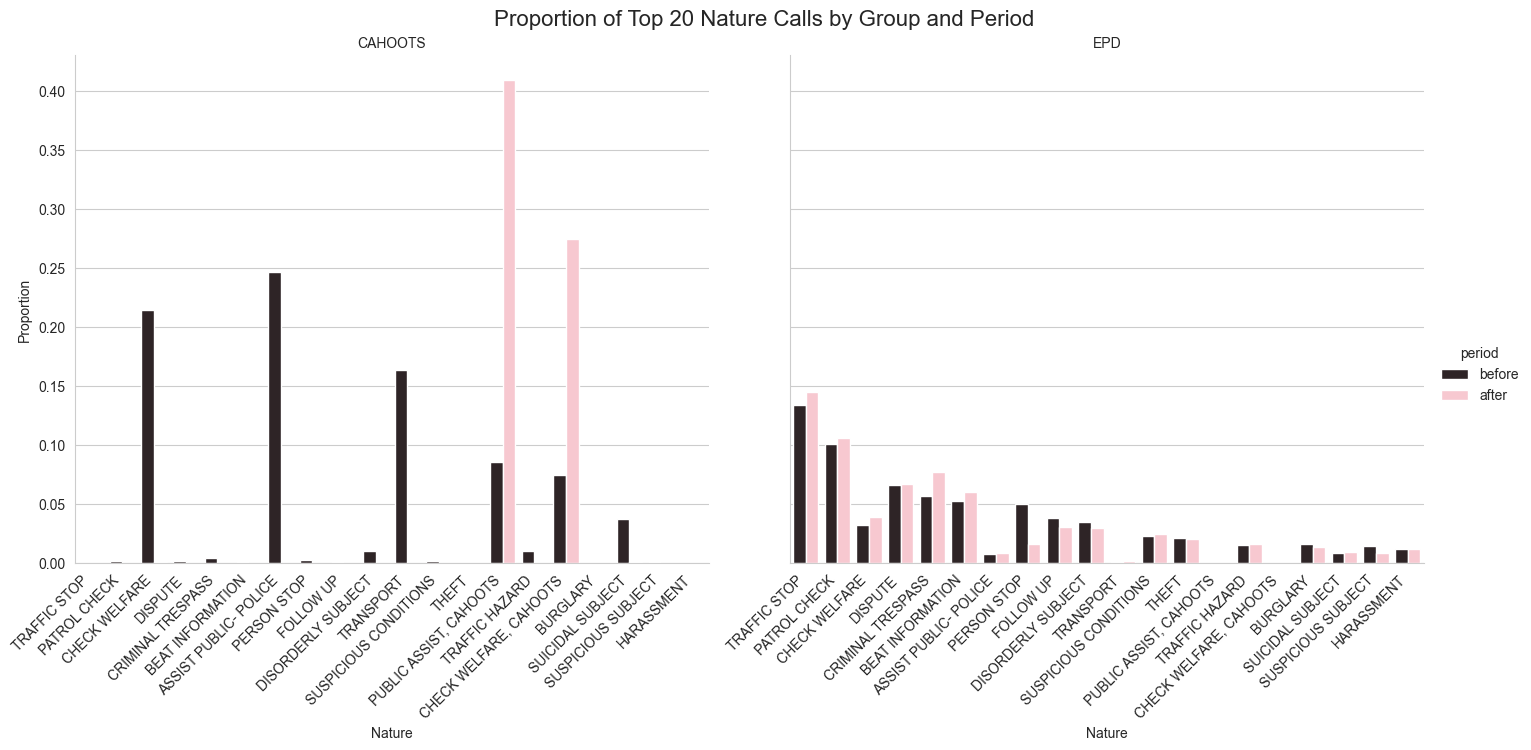

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 20 nature types
top_natures = df_combined['nature'].value_counts().nlargest(20).index

# Prepare data for plotting proportions
plot_data = []

for nature in top_natures:
    for group in ['CAHOOTS', 'EPD']:
        for period in ['before', 'after']:
            subset = df_combined[(df_combined['nature'] == nature) &
                                 (df_combined['group'] == group) &
                                 (df_combined['period'] == period)]
            
            total = df_combined[(df_combined['group'] == group) &
                                (df_combined['period'] == period)].shape[0]
            
            proportion = len(subset) / total if total > 0 else 0
            
            plot_data.append({
                'nature': nature,
                'group': group,
                'period': period,
                'proportion': proportion
            })

plot_df = pd.DataFrame(plot_data)

# Plot grouped barplot using seaborn
plt.figure(figsize=(18, 10))
sns.set_style('whitegrid')

g = sns.catplot(
    data=plot_df,
    x='nature', y='proportion',
    hue='period',
    col='group',
    kind='bar',
    height=6, aspect=1.2,
    #palette='muted',
    color = 'pink')

g.set_axis_labels("Nature", "Proportion")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, horizontalalignment='right')
g.fig.suptitle('Proportion of Top 20 Nature Calls by Group and Period', fontsize=16, y=1.02)

plt.show()


/var/folders/6w/4r6pgcmd4436v0911mggkjzc0000gn/T/ipykernel_31433/3994597158.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pval_df, x='nature', y='p_value', palette='coolwarm')


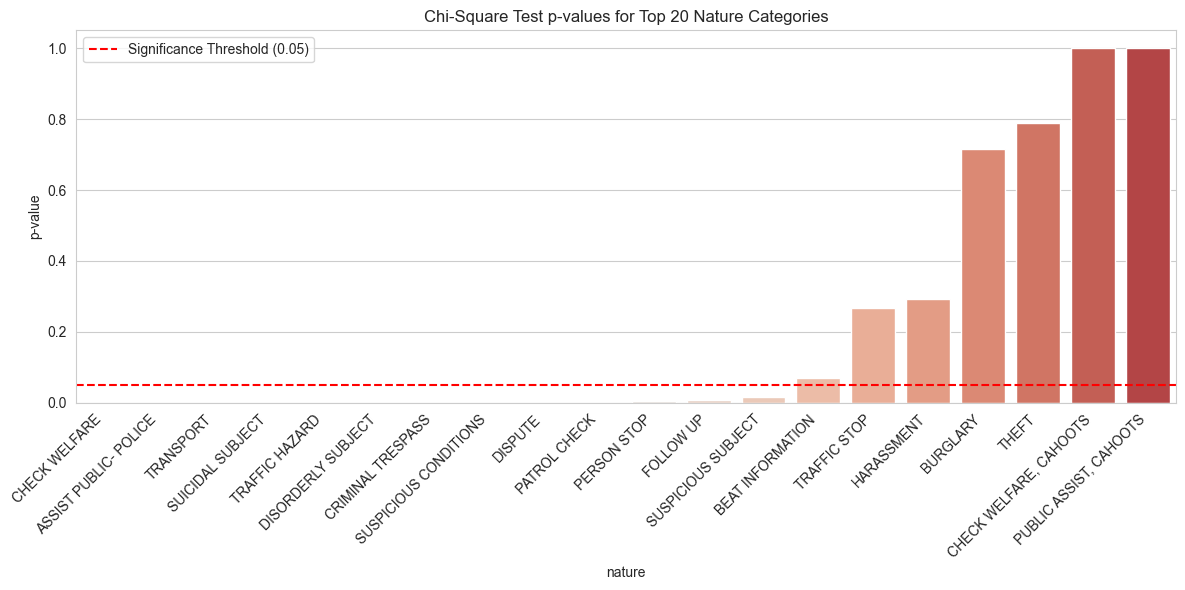

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Get top 20 most common nature types
top_natures = df_combined['nature'].value_counts().nlargest(20).index

# Collect p-values
p_values = []

for nature in top_natures:
    contingency = pd.crosstab(
        df_combined['group'],
        df_combined['period'],
        values=(df_combined['nature'] == nature),
        aggfunc='sum'
    ).fillna(0).astype(int)

    # Skip if incomplete table
    if contingency.shape != (2, 2):
        continue

    chi2, p, dof, expected = chi2_contingency(contingency.values)
    p_values.append({'nature': nature, 'p_value': p})

pval_df = pd.DataFrame(p_values).sort_values('p_value')

# Plot p-values
plt.figure(figsize=(12, 6))
sns.barplot(data=pval_df, x='nature', y='p_value', palette='coolwarm')

plt.axhline(0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('p-value')
plt.title('Chi-Square Test p-values for Top 20 Nature Categories')
plt.legend()
plt.tight_layout()
plt.show()
